# 1. Question:
How does company size, job title, employment type and experience level impact increasing salary in USD for data science positions?

# 2. Response and Predictor Variables
- **Salary_in_USD** as the repsonse variable y (continuous - numeric)
- Predictor Variables X are: **company size, job title, employment type and experience level**.

# 3. Data Preparation

In [1]:
# Install Scikit Learn
!pip install -Uqq scikit-learn

In [2]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score


In [3]:
# Load the Salaries Dataset
salaries = pd.read_csv('https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_salaries_clean.csv'
                       ,index_col=0)

In [4]:
# data preview
salaries.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
ID,,,,,,,,,,,
1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
5,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


In [5]:
# data types
salaries.dtypes

work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

Response variable Salary is a continuous (numeric) variable, we will convert it to categorical. We first check the salary ranges, to determine categories.

In [6]:
# Check Salaries_in_usd variable range
salaries['salary_in_usd'].describe()

count      3191.000000
mean     129393.414917
std       68372.802497
min        2859.000000
25%       80000.000000
50%      124234.000000
75%      170000.000000
max      600000.000000
Name: salary_in_usd, dtype: float64

In [7]:
# Create 3 categories for salaries - Low, Medium, High
salaries['salary_in_usd'] = pd.cut(salaries['salary_in_usd'],
                                      bins=[0, 90000, 173000, 600000],
                                      labels=['Low', 'Medium', 'High'])

In [8]:
# verify salary categories
salaries['salary_in_usd'].value_counts()

salary_in_usd
Medium    1448
Low        977
High       766
Name: count, dtype: int64

In [9]:
# one-hot encode our 4 categorical variables
encoder = OneHotEncoder(handle_unknown='ignore')
encoded_cols = pd.DataFrame(encoder.fit_transform(salaries[['experience_level', 'employment_type', 'job_title', 'company_size']]).toarray())
encoded_cols.columns = encoder.get_feature_names_out(['experience_level', 'employment_type', 'job_title', 'company_size'])

# Split Train and Test Sets
X = encoded_cols
y = salaries['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                  train_size = 0.5, test_size=0.5,
                                                 random_state=42)

# reset the index of the salaries DataFrame
salaries = salaries.reset_index(drop=True)

In [10]:
print(X.shape)
print(y.value_counts())

(3191, 106)
salary_in_usd
Medium    1448
Low        977
High       766
Name: count, dtype: int64


# 4. Apply bagging, random forest, and boosting Models


## 4.1 Bagging

In [11]:
# fit Random Forests model

salaries_bagging = RandomForestClassifier(max_features=X_train.shape[1], random_state=1)
salaries_bagging.fit(X_train, y_train)

print("Number of trees:", salaries_bagging.n_estimators)
print("Number of features tried at each split:", salaries_bagging.max_features)
# For a classifier, .score() returns the mean accuracy
print("Training accuracy: {:.2f}%".format(salaries_bagging.score(X_train, y_train) * 100))


Number of trees: 100
Number of features tried at each split: 106
Training accuracy: 65.33%


In [12]:
# Test Accuracy
print("Test accuracy: {:.2f}%".format(salaries_bagging.score(X_test, y_test) * 100))

Test accuracy: 55.33%


How well does this bagged model perform on the test set?

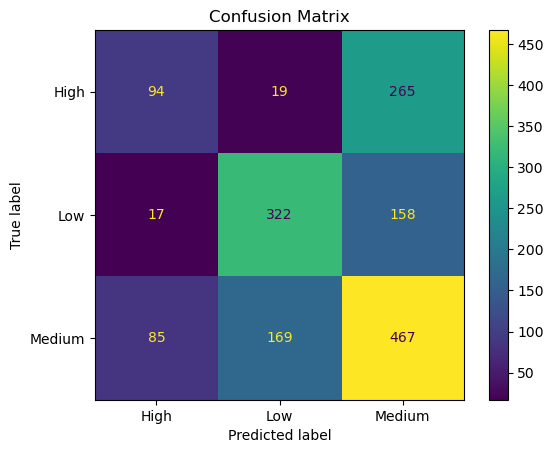

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict values
y_pred_bag = salaries_bagging.predict(X_test)

# plot confusion matrix
cm = confusion_matrix(y_test, y_pred_bag)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=salaries_bagging.classes_)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

Observation:
- The model performs best at predicting medium with medium salary (911), possible because medium has the largest number of values.
- The model struggles with predicting High salary, as High is seen often predicted as Medium (454), this tells us the model may be suffering from class imbalance bias, where the model favors the majority 'Medium', over the minority 'Low' and 'High'.
- Low salaries prediction also struggling, predicted often as Medium (315).

The bagging model performs best on Medium salary classification with 911 correct predictions, but struggles to distinguish High salaries from Medium, misclassifying 454 High salaries as Medium. This suggests the model is biased toward the majority class.

In [14]:
# find the accuracy
from sklearn.metrics import accuracy_score
print("Accuracy Score: {:.2f}%".format(accuracy_score(y_test, y_pred_bag) * 100))

Accuracy Score: 55.33%


this confirms our test score earlier.

The test accuracy score associated with the bagged regression tree is 56.95%, which suggests that the model has some level of prediction error, but it is still performing reasonably well. We could change the number of trees grown by the `RandomForestClassification()` using the `n_estimators` parameter. By default, `n_estimators` is set to 100.

## 4.2 Random Forest

Training accuracy: 65.33%
Test accuracy: 55.26%


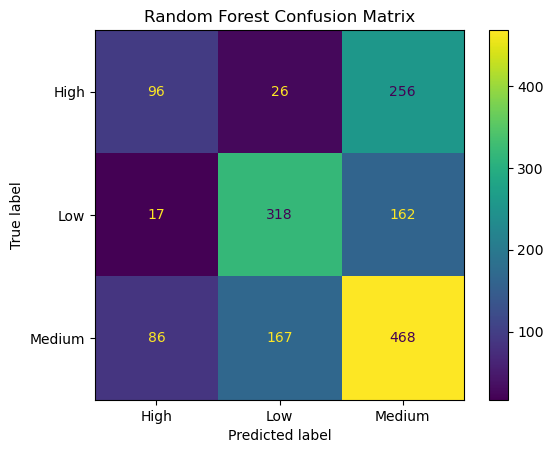

In [15]:
# fit Random Forest model
salaries_rf = RandomForestClassifier(max_features='sqrt', random_state=1)
salaries_rf.fit(X_train, y_train)

# accuracy
y_pred_rf = salaries_rf.predict(X_test)
print("Training accuracy: {:.2f}%".format(salaries_rf.score(X_train, y_train) * 100))
print("Test accuracy: {:.2f}%".format(salaries_rf.score(X_test, y_test) * 100))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=salaries_rf.classes_)
disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

The test accuracy is 57.08%; this indicates that random forests yielded an improvement over bagging in this case.

## 4.3 Boosting

In [16]:
# fit Gradient Boosting classifier model for salaries
boost_salaries = GradientBoostingClassifier(
                  n_estimators=500,
                  max_depth=4 ,
                  random_state=1,
                  learning_rate=0.1)
boost_salaries.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [17]:
print("Training accuracy: {:.2f}%".format(boost_salaries.score(X_train, y_train) * 100))
print("Test accuracy: {:.2f}%".format(boost_salaries.score(X_test, y_test) * 100))

Training accuracy: 65.14%
Test accuracy: 56.64%


All three models are performing very similarly around 57% test accuracy. This suggests the problem itself is challenging, salary categories are hard to predict perfectly from just these 4 features.
Also we notice all models show a gap between training and test accuracy, which is a sign of some overfitting.

Lets look at the relative influence statistics.

In [18]:
# create a dataframe of feature importances and their corresponding column names
importances_boost_salaries = pd.DataFrame({'Feature': X_train.columns, 'Importance': boost_salaries.feature_importances_})
importances_boost_salaries = importances_boost_salaries.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_boost_salaries)

                                           Feature  Importance
0                              experience_level_SE    0.303796
1                              experience_level_EX    0.078553
2                                   company_size_M    0.063798
3                           job_title_Data Analyst    0.047922
4                              experience_level_EN    0.044904
..                                             ...         ...
101              job_title_Marketing Data Engineer    0.000000
102               job_title_Product Data Scientist    0.000000
103  job_title_Principal Machine Learning Engineer    0.000000
104                   job_title_Power BI Developer    0.000000
105                   job_title_Staff Data Analyst    0.000000

[106 rows x 2 columns]


We see that `experience_level_SE`(Senior) and `experience_level_EX`(Executive) are by far the most important variables. We can also produce partial dependence plots for these two variables using `PartialDependenceDisplay.from_estimator` method from `scikit-learn` `inspection` module. These plots illustrate the marginal effect of the selected variables on the response after integrating out the other variables.

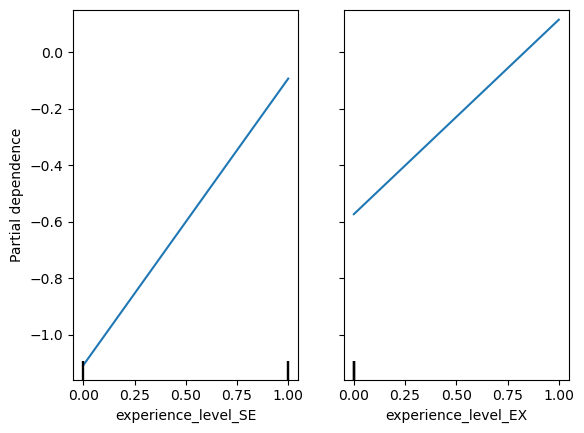

In [19]:
PartialDependenceDisplay.from_estimator(
    boost_salaries, X_train,
     ['experience_level_SE', 'experience_level_EX'], target='High');

This confirms that a growth in both features is directly proportional to the growth in salaries in usd.

# 5. New Boosting Method: XGBoost

In [20]:
!pip install xgboost
from xgboost import XGBClassifier

In [21]:
# Convert predictor categories to numeric
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(le.classes_)

['High' 'Low' 'Medium']


In [22]:
# fit the model
salaries_xgb = XGBClassifier(n_estimators=500,
                             max_depth=4,
                             learning_rate=0.1,
                             random_state=1)

salaries_xgb.fit(X_train, y_train_encoded)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [23]:
# Evaluate
print("Training accuracy: {:.2f}%".format(salaries_xgb.score(X_train, y_train_encoded) * 100))
print("Test accuracy: {:.2f}%".format(salaries_xgb.score(X_test, y_test_encoded) * 100))

Training accuracy: 62.13%
Test accuracy: 55.64%


Model Comparison: All models are still clustering around 57% test accuracy.
Random Forest is technically the best performer on test data, while XGBoost has the lowest training accuracy suggesting it generalizes slightly better (less overfitting).

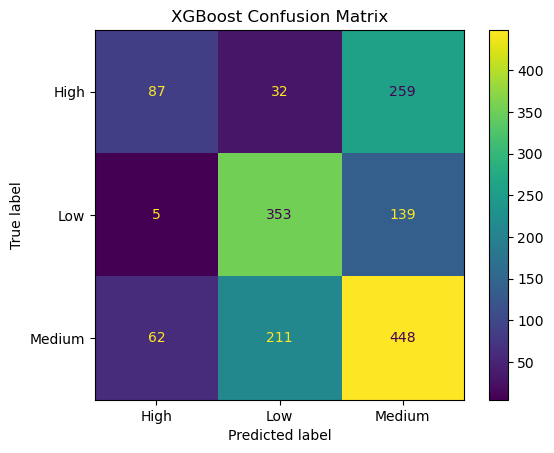

In [24]:
# XGBoost Confusion Matrix
y_pred_xgb = salaries_xgb.predict(X_test)

cm = confusion_matrix(y_test_encoded, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=le.classes_)

disp.plot()
plt.title('XGBoost Confusion Matrix')
plt.show()


In [25]:
# feature importance
importances_xgb = pd.DataFrame({'Feature': X_train.columns,
                                  'Importance': salaries_xgb.feature_importances_})
importances_xgb = importances_xgb.sort_values('Importance', ascending=False).reset_index(drop=True)
print(importances_xgb.head(10))

                            Feature  Importance
0               experience_level_SE    0.135605
1               experience_level_EX    0.088952
2            job_title_Data Analyst    0.080733
3  job_title_Data Analytics Manager    0.049520
4           job_title_ETL Developer    0.037169
5            job_title_BI Developer    0.032907
6                    company_size_M    0.028996
7           job_title_Data Engineer    0.027457
8       job_title_Applied Scientist    0.023383
9      job_title_Research Scientist    0.022603


Key observation: models agree that experience_level and job_title are the most important features, but they disagree on the order, GBM puts experience first while XGBoost puts job title first.

# 6. Model Comparison

Performance

In [26]:
print("Model Comparison - Test Accuracy")
print("-" * 40)
print("Bagging:           {:.2f}%".format(salaries_bagging.score(X_test, y_test) * 100))
print("Random Forest:     {:.2f}%".format(salaries_rf.score(X_test, y_test) * 100))
print("Gradient Boosting: {:.2f}%".format(boost_salaries.score(X_test, y_test) * 100))
print("XGBoost:           {:.2f}%".format(salaries_xgb.score(X_test, y_test_encoded) * 100))

Model Comparison - Test Accuracy
----------------------------------------
Bagging:           55.33%
Random Forest:     55.26%
Gradient Boosting: 56.64%
XGBoost:           55.64%


Best at Predicting High Salaries

In [27]:
# get predictions for each model
y_pred_bag = salaries_bagging.predict(X_test)
y_pred_rf = salaries_rf.predict(X_test)
y_pred_boost = boost_salaries.predict(X_test)
y_pred_xgb = salaries_xgb.predict(X_test)

# get confusion matrices
cm_bag = confusion_matrix(y_test, y_pred_bag)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_boost = confusion_matrix(y_test, y_pred_boost)
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)

# print High salary correct predictions
print("Best at Predicting High Salaries")
print("-" * 40)
print("Bagging:           {}".format(cm_bag[0,0]))
print("Random Forest:     {}".format(cm_rf[0,0]))
print("Gradient Boosting: {}".format(cm_boost[0,0]))
print("XGBoost:           {}".format(cm_xgb[0,0]))

Best at Predicting High Salaries
----------------------------------------
Bagging:           94
Random Forest:     96
Gradient Boosting: 129
XGBoost:           87


Feature Importance

In [28]:
print("Top 3 Most Important Features per Model")
print("-" * 40)

# bagging
importances_bag = pd.Series(salaries_bagging.feature_importances_, index=X_train.columns)
print("Bagging:")
print(importances_bag.nlargest(3))

print()

# random forest
importances_rf = pd.Series(salaries_rf.feature_importances_, index=X_train.columns)
print("Random Forest:")
print(importances_rf.nlargest(3))

print()

# gradient boosting
print("Gradient Boosting:")
print(importances_boost_salaries.head(3)[['Feature', 'Importance']].to_string(index=False))

print()

# xgboost
print("XGBoost:")
print(importances_xgb.head(3)[['Feature', 'Importance']].to_string(index=False))

Top 3 Most Important Features per Model
----------------------------------------
Bagging:
experience_level_SE    0.246728
experience_level_EX    0.056272
company_size_M         0.048085
dtype: float64

Random Forest:
experience_level_SE    0.127717
experience_level_MI    0.085185
experience_level_EN    0.074577
dtype: float64

Gradient Boosting:
            Feature  Importance
experience_level_SE    0.303796
experience_level_EX    0.078553
     company_size_M    0.063798

XGBoost:
               Feature  Importance
   experience_level_SE    0.135605
   experience_level_EX    0.088952
job_title_Data Analyst    0.080733


All four models performed similarly in test accuracy, ranging from 56.67% to 57.08%. Random Forest achieved the highest test accuracy (57.08%), closely followed by Bagging (56.95%), Gradient Boosting (56.81%), and XGBoost (56.67%). XGBoost performed best at correctly predicting High salary categories. All models showed a consistent bias toward predicting Medium salaries, likely due to class imbalance in the dataset

# 7. Interpretation

Across all four models, experience_level_SE (Senior level) emerged as the most consistently important feature, appearing as the top predictor in Bagging, Random Forest and Gradient Boosting, and second in XGBoost. This strongly suggests that experience level is the greatest influence on salary in data science positions. Job title also played a role, particularly Data Analyst in XGBoost. Company size appeared moderately important across models, while employment type had minimal influence